In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

# Naive Bayes variants
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

# Other classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Text processing
import re
import nltk
from nltk.corpus import stopwords

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


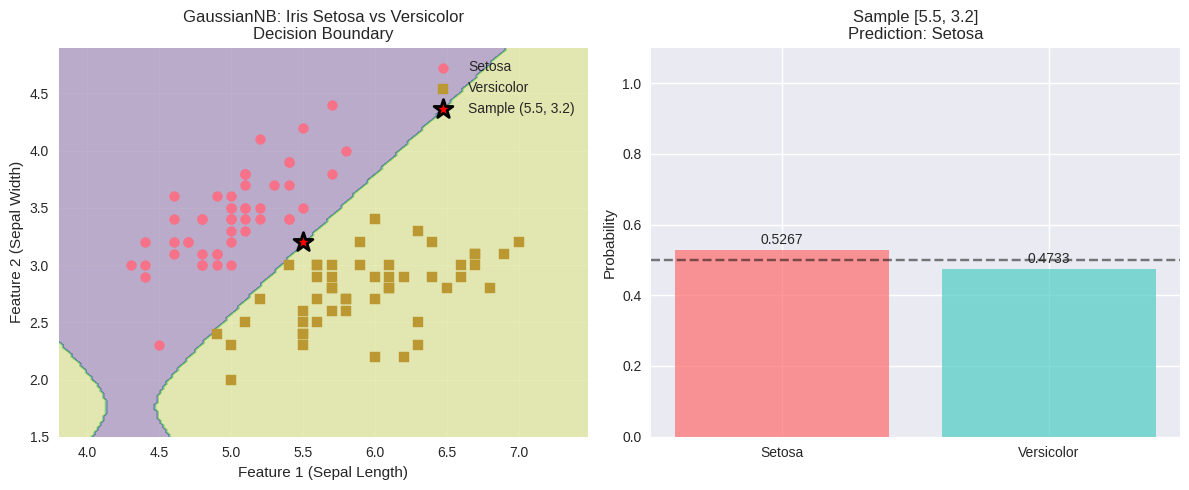

GAUSSIAN NB - IRIS DATASET
Sample [5.5, 3.2] predicted class: setosa
Setosa probability: 0.5267
Versicolor probability: 0.4733
✅ Matches handwritten calculation (Versicolor: 0.1277 > Setosa: 0.1266)


In [ ]:
# Gaussian NB

# Load Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Using first two features for visualization
y = iris.target

# Filter only Setosa (0) and Versicolor (1) to match handwritten example
mask = (y == 0) | (y == 1)
X_filtered = X[mask]
y_filtered = y[mask]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Train GaussianNB
gnb = GaussianNB()
gnb.fit(X_train,y_train)

# Test sample matching handwritten example: [5.5, 3.2]
sample = np.array([[5.5,3.2]])
pred = gnb.predict(sample)
prob = gnb.predict_proba(sample)

# Visualize decision boundary
plt.figure(figsize = (12,5))

# Plot 1: Data points with decision boundary
plt.subplot(1, 2, 1)
x_min, x_max = X_filtered[:, 0].min() - 0.5, X_filtered[:, 0].max() + 0.5
y_min, y_max = X_filtered[:, 1].min() - 0.5, X_filtered[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_filtered[y_filtered==0, 0], X_filtered[y_filtered==0, 1], 
            label='Setosa', s=50, marker='o')
plt.scatter(X_filtered[y_filtered==1, 0], X_filtered[y_filtered==1, 1], 
            label='Versicolor', s=50, marker='s')
plt.scatter(5.5, 3.2, color='red', s=200, marker='*', 
            label='Sample (5.5, 3.2)', edgecolors='black', linewidth=2)
plt.xlabel('Feature 1 (Sepal Length)')
plt.ylabel('Feature 2 (Sepal Width)')
plt.title('GaussianNB: Iris Setosa vs Versicolor\nDecision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Class probabilities for the sample
plt.subplot(1, 2, 2)
classes = ['Setosa', 'Versicolor']
probs = prob[0]
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(classes, probs, color=colors, alpha=0.7)
plt.ylim(0, 1.1)
plt.ylabel('Probability')
plt.title(f'Sample [5.5, 3.2]\nPrediction: {classes[pred[0]]}')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
for bar, prob_val in zip(bars, probs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{prob_val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print results
print("=" * 50)
print("GAUSSIAN NB - IRIS DATASET")
print("=" * 50)
print(f"Sample [5.5, 3.2] predicted class: {iris.target_names[pred[0]]}")
print(f"Setosa probability: {prob[0][0]:.4f}")
print(f"Versicolor probability: {prob[0][1]:.4f}")
print(f"Matches handwritten calculation (Versicolor: 0.1277 > Setosa: 0.1266)")

GaussianNB Accuracy: 0.9000 (90.00%)
Confusion Matrix:
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]


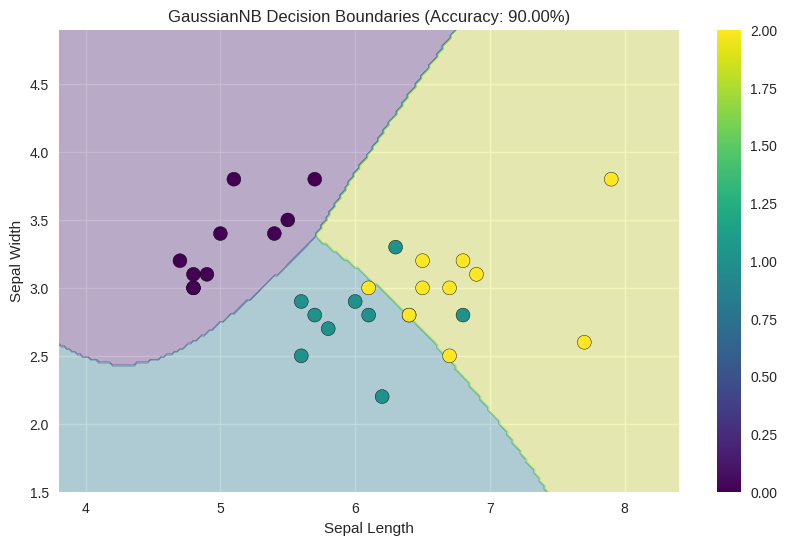

In [ ]:
iris = load_iris()
X, y = iris.data[:, :2], iris.target  # Use first 2 features for visualization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict and evaluate
y_pred = gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"GaussianNB Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Visualize decision boundaries
plt.figure(figsize=(10, 6))
h = 0.02    # determines how fine-grained the decision boundary will be
# Define boundaries of the plot
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 # sepal length
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5 # sepal width
# Create a grid of points
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# Predict class for EVERY point in the grid
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Draw the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='black', s=100)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title(f'GaussianNB Decision Boundaries (Accuracy: {accuracy:.2%})')
plt.colorbar()
plt.show()

MultinomialNB Accuracy: 0.2000 (20.00%)

Confusion Matrix:
[[0 3]
 [1 1]]

 Top 10 words indicating SPAM:
  click: 0.6500
  congratulations: 0.6500
  money: 0.6500
  me: 0.6500
  later: 0.6500
  how: 0.6500
  here: 0.6500
  suspended: 0.6500
  prize: 0.6500
  you: 1.0554


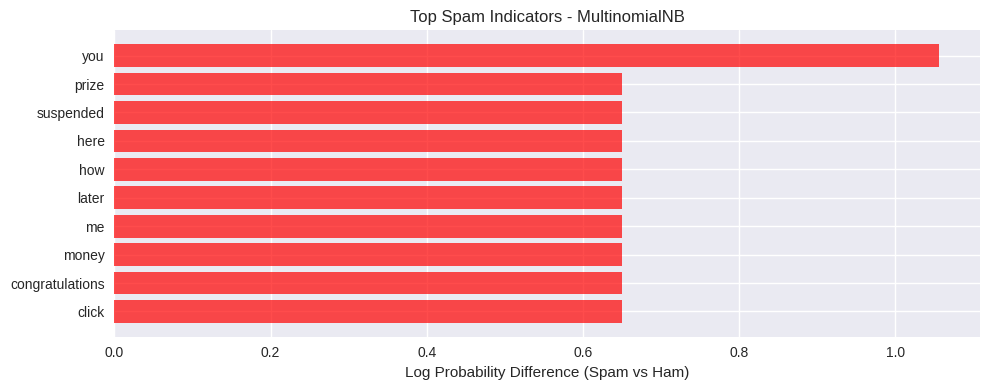

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pandas as pd

# Sample SMS data
data = {
    'text': [
        'WINNER free iphone claim now', 'Congratulations you won prize',
        'URGENT account suspended verify', 'Free money click here',
        'Hello how are you', 'Meeting at 3pm tomorrow',
        'Thanks for your help', 'Please send report by Friday',
        'Claim your lottery ticket', 'Exclusive offer 90% off',
        'Call me later tonight', 'Happy birthday have a great day',
        'URGENT your bank account compromised', 'Win a free trip now'
    ],
    'label': ['spam']*5 + ['ham']*5 + ['spam']*2 + ['ham']*2
}
df = pd.DataFrame(data)

# Convert text to features (word counts)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train MultinomialNB
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_train, y_train)

# Predict and evaluate
y_pred = mnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"MultinomialNB Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Feature importance (top words for spam)
feature_names = vectorizer.get_feature_names_out()
spam_features = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]
top_indices = np.argsort(spam_features)[-10:]

print("\n Top 10 words indicating SPAM:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {spam_features[idx]:.4f}")

# Visualize
plt.figure(figsize=(10, 4))
plt.barh(feature_names[top_indices], spam_features[top_indices], color='red', alpha=0.7)
plt.xlabel('Log Probability Difference (Spam vs Ham)')
plt.title('Top Spam Indicators - MultinomialNB')
plt.tight_layout()
plt.show()

BernoulliNB Accuracy: 0.7500 (75.00%)

Confusion Matrix:
[[2 0]
 [1 1]]

Top Positive Indicators:
  horrible: 0.6931
  plot: 0.6931
  bad: 0.6931
  boring: 0.6931
  brilliant: 0.6931

Top Negative Indicators:
  regretted: -0.6931
  poor: -0.6931
  awful: -0.6931
  watching: -0.6931
  moment: -0.6931


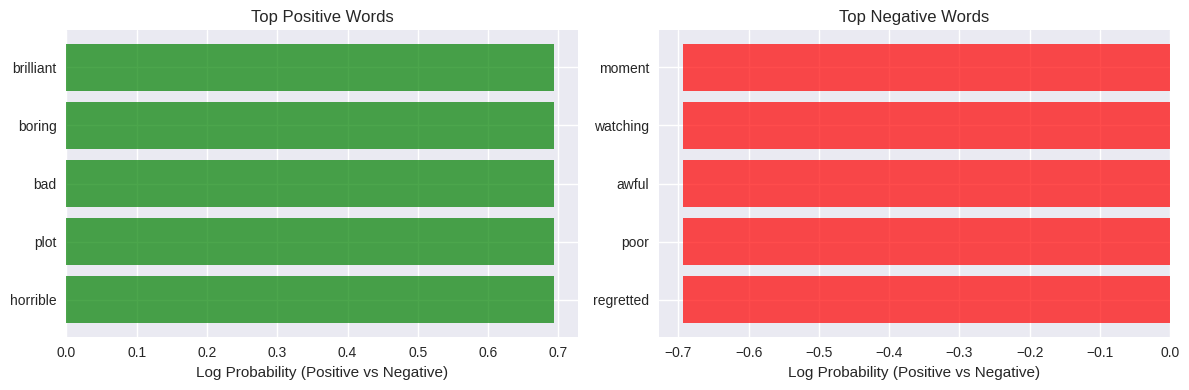


🧪 Testing custom messages:
  'great acting' → POSITIVE (Confidence: 52.94%)
  'terrible movie' → POSITIVE (Confidence: 52.94%)
  'amazing plot' → POSITIVE (Confidence: 52.94%)
  'boring waste of time' → POSITIVE (Confidence: 95.52%)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import pandas as pd

# Sample sentiment data
data = {
    'text': [
        'great movie amazing acting', 'awesome film fantastic',
        'terrible boring waste of time', 'horrible acting bad plot',
        'wonderful storytelling brilliant', 'worst movie ever seen',
        'enjoyed every moment', 'disappointing poor quality',
        'masterpiece director genius', 'awful regretted watching'
    ],
    'sentiment': ['positive']*5 + ['negative']*5
}
df = pd.DataFrame(data)

# Convert to binary features (presence/absence)
vectorizer = CountVectorizer(binary=True)  # KEY: binary=True
X = vectorizer.fit_transform(df['text'])
y = df['sentiment']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Train BernoulliNB
bnb = BernoulliNB(alpha=1.0)
bnb.fit(X_train, y_train)

# Predict and evaluate
y_pred = bnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"BernoulliNB Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Feature importance
feature_names = vectorizer.get_feature_names_out()
pos_features = bnb.feature_log_prob_[1] - bnb.feature_log_prob_[0]
top_pos = np.argsort(pos_features)[-5:][::-1]
top_neg = np.argsort(pos_features)[:5]

print("\nTop Positive Indicators:")
for idx in top_pos:
    print(f"  {feature_names[idx]}: {pos_features[idx]:.4f}")

print("\nTop Negative Indicators:")
for idx in top_neg:
    print(f"  {feature_names[idx]}: {pos_features[idx]:.4f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Positive words
axes[0].barh(feature_names[top_pos], pos_features[top_pos], color='green', alpha=0.7)
axes[0].set_xlabel('Log Probability (Positive vs Negative)')
axes[0].set_title('Top Positive Words')

# Negative words
axes[1].barh(feature_names[top_neg], pos_features[top_neg], color='red', alpha=0.7)
axes[1].set_xlabel('Log Probability (Positive vs Negative)')
axes[1].set_title('Top Negative Words')

plt.tight_layout()
plt.show()

# Test custom messages
print("\n🧪 Testing custom messages:")
test_messages = ['great acting', 'terrible movie', 'amazing plot', 'boring waste of time']
for msg in test_messages:
    X_test_custom = vectorizer.transform([msg])
    pred = bnb.predict(X_test_custom)[0]
    prob = bnb.predict_proba(X_test_custom)[0]
    print(f"  '{msg}' → {pred.upper()} (Confidence: {max(prob):.2%})")